
# Experiment-Auswertung (Random Forest, Edge)

Dieses Notebook wertet deine **Random_Forest / Edge**-Experimente aus.  
Es sucht nach Error-Metrics und Step-Predictions, berechnet Mittelwerte **ohne den ersten Schritt** und erzeugt Heatmaps (Lags × Horizon) für **Inferenzzeit**, **CPU** und **RAM**.

> Passe im nächsten Block ggf. den Pfad an (Windows-Format ist ok). Standard ist dein Ordner:
>
> `C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Output\Random_Forest`


In [6]:

# --- Konfiguration ---
from pathlib import Path

# Root(s) mit deinen Runs (kann auch eine Liste sein)
ROOTS = [
    r"C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Output\LSTM"
]

ALGORITHM = "LSTM"
PROFILE   = "edge"

# Ergebnisordner (wird erzeugt, wenn nicht vorhanden)
OUT_DIR = Path(ROOTS[0]) / "Analysis"
print("Roots:", ROOTS)
print("Out dir:", OUT_DIR)

Roots: ['C:\\Users\\ericg\\Documents\\Mechatronik M Sc\\6. Semster\\MA\\Dev_Ma\\ML_Edge_Device\\Output\\LSTM']
Out dir: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Output\LSTM\Analysis


In [7]:

# --- Imports & Setup ---
import os, json, re
from typing import List, Optional, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

# Matplotlib: große, klare Plots
%matplotlib inline
plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 120

## Hilfsfunktionen

In [8]:

def find_files(patterns: List[str], roots: List[Path]) -> List[Path]:
    hits = []
    for root in roots:
        root = Path(root)
        if not root.exists():
            continue
        for pat in patterns:
            hits.extend(root.rglob(pat))
    # de-duplicate while preserving order
    uniq = []
    seen = set()
    for p in hits:
        if p not in seen:
            uniq.append(p)
            seen.add(p)
    return uniq

def safe_float(x):
    try:
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return np.nan
        return float(x)
    except Exception:
        return np.nan

def read_json(fp: Path) -> Optional[dict]:
    try:
        with open(fp, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return None

def step_csv_skip_first(df: pd.DataFrame) -> pd.DataFrame:
    """
    Entfernt den **ersten Schritt** pro Session/Run, falls eine ID-Spalte vorhanden ist.
    Wenn keine ID-Spalte existiert, wird die **erste Zeile** der Datei entfernt.
    """
    cand_cols = [c for c in df.columns if re.search(r"(step|session|run).*id", c, flags=re.I)]
    if cand_cols:
        cid = cand_cols[0]
        return df.groupby(cid, as_index=False, group_keys=False).apply(lambda g: g.iloc[1:])
    else:
        return df.iloc[1:, :]

## Kernlogik: Aggregation & Heatmaps

In [9]:

def summarize_step_predictions(step_csv: Path) -> Dict[str, float]:
    df = pd.read_csv(step_csv)
    df = step_csv_skip_first(df)
    out = {}
    for col in ["inference_time_s", "total_time_s", "cpu_percent", "ram_percent"]:
        if col in df.columns:
            out[f"{col}_mean"] = float(pd.to_numeric(df[col], errors="coerce").dropna().mean())
        else:
            out[f"{col}_mean"] = np.nan
    out["n_steps_used"] = int(len(df))
    return out

def pivot_and_plot(df: pd.DataFrame, value_col: str, title: str, outfile: Path = None):
    if not {"lags","horizon", value_col}.issubset(df.columns):
        print(f"[WARN] Spalten fehlen für Plot: {value_col}")
        return None
    p = df.pivot_table(index="lags", columns="horizon", values=value_col, aggfunc="mean")
    if p.empty:
        print(f"[WARN] Keine Daten für Plot: {value_col}")
        return None
    fig, ax = plt.subplots()
    im = ax.imshow(p.values, aspect="auto")
    ax.set_xticks(np.arange(len(p.columns)))
    ax.set_xticklabels(p.columns)
    ax.set_yticks(np.arange(len(p.index)))
    ax.set_yticklabels(p.index)
    ax.set_xlabel("Horizon")
    ax.set_ylabel("Lags")
    ax.set_title(title)
    for i in range(p.shape[0]):
        for j in range(p.shape[1]):
            val = p.values[i, j]
            if not (isinstance(val, float) and np.isnan(val)):
                ax.text(j, i, f"{val:.3g}", ha="center", va="center")
    fig.tight_layout()
    if outfile:
        outfile.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outfile, dpi=200, bbox_inches="tight")
        print("[OK] Saved:", outfile)
    plt.show()
    return outfile

def evaluate_experiments(search_roots: List[Path], algorithm: str, profile: str, out_dir: Path):
    algo_key = algorithm.lower()
    profile_key = profile.lower()

    agg_csv_candidates = find_files(["ErrorMetrics_all_runs.csv"], search_roots)
    json_candidates = find_files([
        "ErrorMetrics_*_train_*_*.json",
        "ErrorMetrics_*_infer_*_*.json",
        "ErrorMetrics_*.json"
    ], search_roots)
    step_csv_candidates = find_files(["StepPredictions_*.csv"], search_roots)

    run_rows = []
    if agg_csv_candidates:
        try:
            df_all = pd.read_csv(agg_csv_candidates[0])
            f = pd.Series([True] * len(df_all))
            for c, val in (("algorithm", algo_key), ("profile", profile_key), ("model_name", f"{algo_key}_{profile_key}")):
                if c in df_all.columns:
                    f = f & df_all[c].astype(str).str.lower().str.contains(val, na=False)
            run_rows = df_all[f.fillna(False)].to_dict(orient="records")
        except Exception as e:
            print("[WARN] Konnte ErrorMetrics_all_runs.csv nicht lesen:", e)

    if not run_rows:
        for j in json_candidates:
            js = read_json(j)
            if not js:
                continue
            run_rows.append({"json_path": str(j)})

    for r in run_rows:
        if "json_path" not in r and "json" in r:
            r["json_path"] = r["json"]

    records = []
    for row in run_rows:
        js = None
        p = None
        if "json_path" in row and isinstance(row["json_path"], str):
            p = Path(row["json_path"])
            if not p.exists():
                candidates = find_files([p.name], search_roots)
                p = candidates[0] if candidates else p
            if p.exists():
                js = read_json(p)

        if not js:
            continue

        tr = js.get("training_config", {}) or {}
        inf = js.get("inference_config", {}) or {}
        run_id = js.get("run", {}).get("run_id") or tr.get("run_id") or inf.get("run_id") or ""

        model_name = (tr.get("model_name") or inf.get("model_name") or "").lower()
        is_algo_match = (algo_key in model_name) or (algorithm.replace("_"," ").title().replace(" ", "_") in (tr.get("paths", {}) or {}).get("Base_Output_Path",""))
        if not is_algo_match and algo_key not in (tr.get("model_name","") + inf.get("model_name","")).lower():
            continue

        lags = tr.get("lags", inf.get("lags", np.nan))
        horizon = tr.get("horizon", inf.get("horizon", np.nan))
        model_size = tr.get("model_size_MB", inf.get("model_size_MB", np.nan))
        training_time = tr.get("training_time_s", np.nan)
        model_tag = (js.get("extra_info", {}) or {}).get("model_tag", "")

        pred_path = (js.get("extra_info", {}) or {}).get("predictions_file_path", "")
        pred = Path(pred_path) if pred_path else None
        if not pred or not pred.exists():
            if run_id:
                pat = f"StepPredictions_{run_id}_*.csv"
                hits = find_files([pat], search_roots)
                pred = hits[0] if hits else None
        if not pred or not pred.exists():
            pred = step_csv_candidates[0] if step_csv_candidates else None

        metrics = {
            "inference_time_s_mean": np.nan,
            "total_time_s_mean": np.nan,
            "cpu_percent_mean": np.nan,
            "ram_percent_mean": np.nan,
            "n_steps_used": 0,
        }
        if pred and pred.exists():
            try:
                m = summarize_step_predictions(pred)
                metrics.update(m)
            except Exception as e:
                print("[WARN] Konnte StepPredictions nicht auswerten:", pred, e)

        rec = {
            "algorithm": algorithm,
            "profile": profile,
            "lags": int(lags) if not pd.isna(lags) else np.nan,
            "horizon": int(horizon) if not pd.isna(horizon) else np.nan,
            "model_variant": model_tag or "unknown",
            "model_size_mb": safe_float(model_size),
            "training_time_s": safe_float(training_time),
            "run_id": run_id,
            "step_csv": str(pred) if pred else "",
        }
        rec.update(metrics)
        records.append(rec)

    if not records:
        df = pd.DataFrame(columns=[
            "algorithm","profile","lags","horizon","model_variant",
            "inference_time_s_mean","total_time_s_mean","cpu_percent_mean","ram_percent_mean",
            "model_size_mb","training_time_s","run_id","step_csv","n_steps_used"
        ])
    else:
        df = pd.DataFrame(records).drop_duplicates(subset=["run_id","lags","horizon","model_variant"]).sort_values(["lags","horizon"])

    out_dir.mkdir(parents=True, exist_ok=True)
    summary_csv = out_dir / "Experiment_Aggregated_Summary.csv"
    df.to_csv(summary_csv, index=False)
    print("[OK] Summary gespeichert:", summary_csv)

    # Plots (inline + Speichern)
    pivot_and_plot(df, "inference_time_s_mean", "Ø Inference Time (s)", out_dir / "charts" / "heatmap_inference_time.png")
    pivot_and_plot(df, "cpu_percent_mean", "Ø CPU (%)", out_dir / "charts" / "heatmap_cpu.png")
    pivot_and_plot(df, "ram_percent_mean", "Ø RAM (%)", out_dir / "charts" / "heatmap_ram.png")

    return df, summary_csv

## Ausführen

[OK] Summary gespeichert: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Output\LSTM\Analysis\Experiment_Aggregated_Summary.csv
[OK] Saved: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Output\LSTM\Analysis\charts\heatmap_inference_time.png


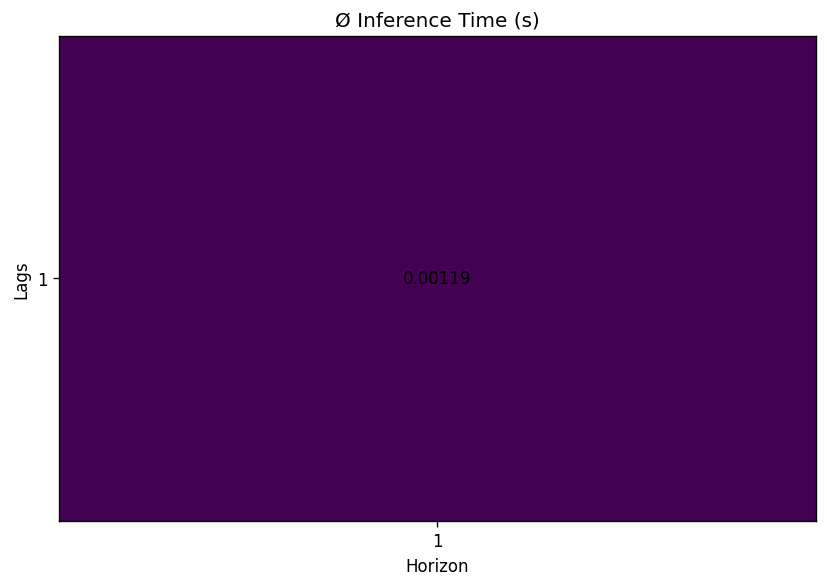

[OK] Saved: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Output\LSTM\Analysis\charts\heatmap_cpu.png


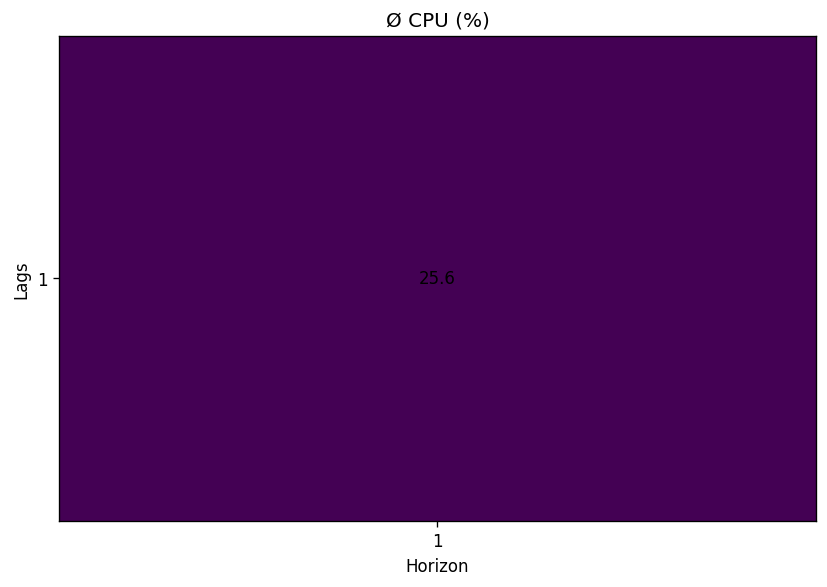

[OK] Saved: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Output\LSTM\Analysis\charts\heatmap_ram.png


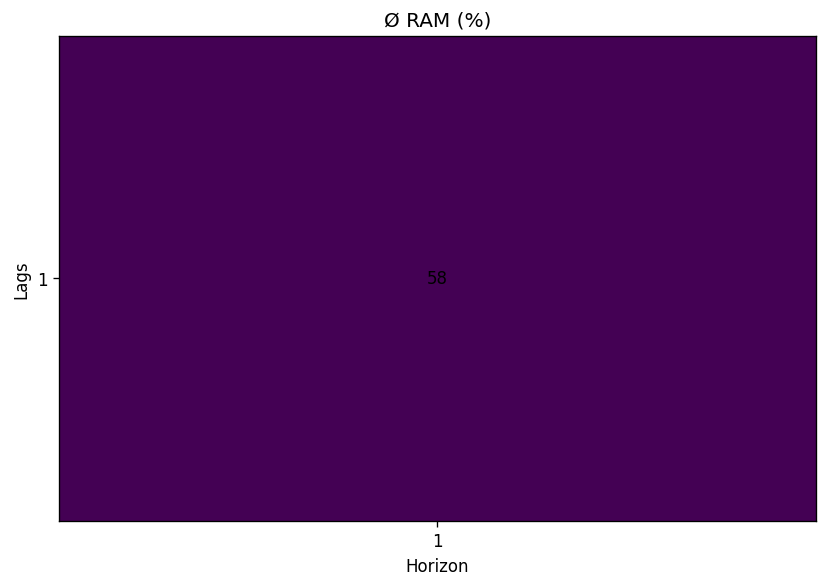

,algorithm,profile,lags,horizon,model_variant,model_size_mb,training_time_s,run_id,step_csv,inference_time_s_mean,total_time_s_mean,cpu_percent_mean,ram_percent_mean,n_steps_used
0,LSTM,edge,1,1,tflite_model_quant_float16,0.1438,57.062,2025-08-24_093035_3163_train,C:\Users\ericg\Documents\Mechatronik M Sc\6. S...,0.001192,0.029142,25.604193,58.003448,58


In [10]:

df_summary, summary_csv = evaluate_experiments(ROOTS, ALGORITHM, PROFILE, OUT_DIR)
df_summary.head(20)